<a href="https://colab.research.google.com/github/Similoluwa224/AI-Modeling/blob/main/Fall_Armyworm_Supervised_AI_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FALL ARMYWORM SUPERVISED LEARNING AI DETECTION**

*AN AI CAPSTONE PROJECT*

*BY SIMILOLUWA OKUSANYA*

## **TABLE OF CONTENTS**

## **1.0 INTRODUCTION**


### 1.1 Background
The Fall Armyworm is a major invasive agricultural pest causing significant crop loss globally, with an average of **31% annual maize loss** in Africa. Early and accurate detection is crucial for effective pest management. Participants will design, train, and evaluate a supervised AI model to identify the presence of FAW (larvae, pupae, moths, or infestation signs like damage) from visual input.
The primary goal is to produce a **compact, deployable, and performant AI model** compatible with the **Open Neural Network Exchange (ONNX)** format, enabling easy integration into various real-world applications.

### 1.2 Objectives
1. To apply supervised learning to detect Fall Armyworm from images or videos.

2. To build and train a computer vision model for FAW classification or detection.

3. To optimize the model for accuracy and efficiency in limited computing environments.

4. To prepare the model for deployment by exporting to the ONNX format.

5. To ensure reproducibility through clear documentation of the ML pipeline.


### 1.3 Dataset Overview

The FAW Dataset used in this project was created by combining and refining data from two publicly available Kaggle sources:

- [Makerere Fall Armyworm Crop Challenge Dataset](https://www.kaggle.com/datasets/gauravduttakiit/makerere-fall-armyworm-crop-challenge) — provided images of healthy and FAW-damaged maize leaves.

- [Fall Armyworm Dataset (Shruthi11sivagnanam)](https://www.kaggle.com/datasets/shruthi11sivagnanam/fall-armyworm) — supplied images showing the presence of FAW larvae on maize plants.

The merged dataset was curated to support supervised image classification for detecting the presence of Fall Armyworm or its damage symptoms.


## **2.0 DATA PREPARATION**

### 2.1 Importation of Libraries

In [1]:
#Import Libraries

## For data manipulation and managing dataset folders
import pandas as pd, os, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

## For ML & Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### 2.2 Loading FAW Dataset Folder

In [2]:
# Loading dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
base_dir = "/content/drive/My Drive/Colab Notebooks/FAW_Dataset"
img_dir = os.path.join(base_dir, "images")

### 2.3 Creating a Unified CSV File

In [4]:
# For healthy dataframe

## Loading healthy.csv
healthy_csv = os.path.join(base_dir, "healthy.csv")
healthy_df = pd.read_csv(healthy_csv)

## Renamed "Image_id" column to "filename", and "Label" to "label"
rename_map = {}
for col in healthy_df.columns:
    if col.strip().lower() == "image_id":
        rename_map[col] = "filename"
    elif col.strip().lower() == "label":
        rename_map[col] = "label"

if rename_map:
    healthy_df.rename(columns=rename_map, inplace=True)
    print("Renamed columns:", rename_map)
else:
    print("No matching columns found to rename. Existing columns:", healthy_df.columns.tolist())

# Save as a new CSV
new_csv_path = os.path.join(base_dir, "healthy_renamed.csv")
healthy_df.to_csv(new_csv_path, index=False)

print(f"Saved new file as: {new_csv_path}")

Renamed columns: {'Image_id': 'filename', 'Label': 'label'}
Saved new file as: /content/drive/My Drive/Colab Notebooks/FAW_Dataset/healthy_renamed.csv


In [5]:
# Determining unlabeled FAW_damage data

healthy_df["label"] = 0   # Healthy = 0

## All image files in images/
all_images = [f for f in os.listdir(img_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

## Images that are NOT in healthy.csv
healthy_files = set(healthy_df["filename"].apply(lambda x: os.path.basename(x)))
damaged_files = [f for f in all_images if f not in healthy_files]

print(f"Healthy images found in CSV: {len(healthy_files)}")
print(f"Remaining FAW_damage images: {len(damaged_files)}")
print("Healthy samples:", len(healthy_df))
healthy_df.head()

Healthy images found in CSV: 1080
Remaining FAW_damage images: 1619
Healthy samples: 1080


,filename,label
0,id_00exusbkgzw1b.jpg,0
1,id_03dqinf6w0znv.jpg,0
2,id_046yl0cxn3ybz.jpg,0
3,id_04athdtx2abyg.jpg,0
4,id_062aauf9e9jk0.jpg,0


In [6]:
# For FAW_damage dataframe

## Creating FAW_damage dataframe
damage_df = pd.DataFrame({
    "filename": [f"images/{f}" for f in damaged_files],
    "label": 1
})

## Standardized healthy samples file path
healthy_df["filename"] = healthy_df["filename"].apply(
    lambda x: f"images/{os.path.basename(x)}"
)

damage_df.to_csv(os.path.join(base_dir, "FAW_damage.csv"), index=False)
print("FAW_damage.csv created with", len(damage_df), "samples.")

FAW_damage.csv created with 1619 samples.


In [7]:
# For FAW_larva dataframe

## FAW_larva images and its CSV
larva_info = {
    "train": "train_file.csv",
    "test": "test_file.csv",
    "valid": "valid_file.csv"
}

## Destination folder for all labeled FAW_larva images
dest_dir = os.path.join(base_dir, "images", "FAW_larva")
os.makedirs(dest_dir, exist_ok=True)

larva_rows = []  # store filename plus label for CSV

for folder, csv_name in larva_info.items():
    folder_path = os.path.join(base_dir, folder)
    csv_path = os.path.join(folder_path, csv_name)

    if not os.path.exists(csv_path):
        print(f"No CSV found in {folder}")
        continue

    ## Reading CSV
    df = pd.read_csv(csv_path)
    print(f"Reading {csv_path} — total rows: {len(df)}")

    ## Keeping only rows labeled 1 in "fall-armyworm" column
    subset = df[df[" fall-armyworm"] == 1]
    print(f"{folder}: {len(subset)} FAW_larva-labeled images found.")

    ## Copying only labeled larva images to unified folder
    for fname in subset["filename"]:
        src = os.path.join(folder_path, fname)
        if os.path.exists(src):
            new_name = os.path.basename(fname)
            dst = os.path.join(dest_dir, new_name)
            shutil.copy(src, dst)
            larva_rows.append({
                "filename": f"images/FAW_larva/{new_name}",
                "label": 2
            })
        else:
            print(f"Missing image file: {fname}")

Reading /content/drive/My Drive/Colab Notebooks/FAW_Dataset/train/train_file.csv — total rows: 312
train: 312 FAW_larva-labeled images found.
Reading /content/drive/My Drive/Colab Notebooks/FAW_Dataset/test/test_file.csv — total rows: 17
test: 17 FAW_larva-labeled images found.
Reading /content/drive/My Drive/Colab Notebooks/FAW_Dataset/valid/valid_file.csv — total rows: 32
valid: 32 FAW_larva-labeled images found.


In [8]:
# Saving the combined larva labels as CSV
larva_df = pd.DataFrame(larva_rows)
larva_csv = os.path.join(base_dir, "FAW_larva.csv")
larva_df.to_csv(larva_csv, index=False)

print(f"\nExtracted and labeled {len(larva_df)} FAW_larva images.")
print(f"Saved FAW larva labels to {larva_csv}")


Extracted and labeled 361 FAW_larva images.
Saved FAW larva labels to /content/drive/My Drive/Colab Notebooks/FAW_Dataset/FAW_larva.csv


In [9]:
# Combining all dataframes into a unified CSV
healthy_df = pd.read_csv(os.path.join(base_dir, "healthy_renamed.csv"))
damage_df = pd.read_csv(os.path.join(base_dir, "FAW_damage.csv"))
larva_df = pd.read_csv(os.path.join(base_dir, "FAW_larva.csv"))

combined_df = pd.concat([healthy_df, damage_df, larva_df], ignore_index=True)
combined_df.to_csv(os.path.join(base_dir, "labels_complete.csv"), index=False)

print("Combined dataset size:", len(combined_df))
print(combined_df['label'].value_counts())


Combined dataset size: 3060
label
1    1619
0    1080
2     361
Name: count, dtype: int64


## **3.0 DATA CLEANING**

### 3.1 Loading Combined CSV

In [10]:
csv_path = os.path.join(base_dir, "labels_complete.csv")
df = pd.read_csv(csv_path)
print("Loaded dataset:", len(df), "samples")
df.head()

Loaded dataset: 3060 samples


,filename,label
0,id_00exusbkgzw1b.jpg,0
1,id_03dqinf6w0znv.jpg,0
2,id_046yl0cxn3ybz.jpg,0
3,id_04athdtx2abyg.jpg,0
4,id_062aauf9e9jk0.jpg,0


### 3.2 Checking for Missing Files

In [11]:
# Getting all files existing in the "images/" folder and its subfolder
missing = []
img_dir = os.path.join(base_dir, "images")
available_files = set()

for root, _, files in os.walk(img_dir):
    for f in files:
        available_files.add(f)  # store only filenames, not paths

## Checking CSV filenames which don't exist in this set
for f in df['filename']:
       fname = os.path.basename(f)  # get only the filename (remove any path)
       if fname not in available_files:
        missing.append(fname)

print(f"Missing files: {len(missing)}")
if missing:
    print("Example missing files:", missing[:10])
else:
    print("All listed images found inside 'images/' folder.")

Missing files: 0
All listed images found inside 'images/' folder.


In [12]:
# Checking which filenames don't start with "images/"
no_prefix = df[~df['filename'].str.lower().str.startswith("images/")]
print(f"Filenames missing 'images/' prefix: {len(no_prefix)}")

# Showing a few examples
no_prefix.head(10)


Filenames missing 'images/' prefix: 1080


,filename,label
0,id_00exusbkgzw1b.jpg,0
1,id_03dqinf6w0znv.jpg,0
2,id_046yl0cxn3ybz.jpg,0
3,id_04athdtx2abyg.jpg,0
4,id_062aauf9e9jk0.jpg,0
5,id_0695b3b665yet.jpg,0
6,id_06cueqs5yhekm.jpg,0
7,id_0826dbdkr8sxr.jpg,0
8,id_09re5drh85tbo.jpg,0
9,id_0adud1myz8tvz.jpg,0


In [13]:
# Added "images/" prefix for any file that doesn’t already have it
df['filename'] = df['filename'].apply(
    lambda x: f"images/{x}" if not str(x).lower().startswith("images/") else x
)

# Saved fixed version
fixed_csv = os.path.join(base_dir, "labels_complete_fixed.csv")
df.to_csv(fixed_csv, index=False)
print("Saved corrected CSV as:", fixed_csv)

Saved corrected CSV as: /content/drive/My Drive/Colab Notebooks/FAW_Dataset/labels_complete_fixed.csv


## **4.0 EXPLORATORY DATA ANALYSIS**

### 4.1 Loading Cleaned Dataset

In [14]:
csv_path = os.path.join(base_dir, "labels_complete_fixed.csv")
df = pd.read_csv(csv_path)
print("Loaded dataset:", len(df), "samples")
df.head()

Loaded dataset: 3060 samples


,filename,label
0,images/id_00exusbkgzw1b.jpg,0
1,images/id_03dqinf6w0znv.jpg,0
2,images/id_046yl0cxn3ybz.jpg,0
3,images/id_04athdtx2abyg.jpg,0
4,images/id_062aauf9e9jk0.jpg,0


In [15]:
# Double-checking the label distribution
print("\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
1    1619
0    1080
2     361
Name: count, dtype: int64


In [16]:
# Checking for duplicates
duplicates = df['filename'].duplicated().sum()
print(f"Duplicate filenames: {duplicates}")

# Checking for missing image files
missing = [f for f in df['filename'] if not os.path.exists(os.path.join(base_dir, f))]
print(f"Missing image files: {len(missing)}")

# Checking for unexpected label values
unique_labels = sorted(df['label'].unique())
print("Unique labels:", unique_labels)

# Ensuring valid labels
if not set(unique_labels).issubset({0, 1, 2}):
    print("Unexpected label detected! Please verify.")
else:
    print("Labels correctly encoded as {0, 1, 2}")

Duplicate filenames: 0
Missing image files: 0
Unique labels: [np.int64(0), np.int64(1), np.int64(2)]
Labels correctly encoded as {0, 1, 2}


### 4.2 Class Distribution

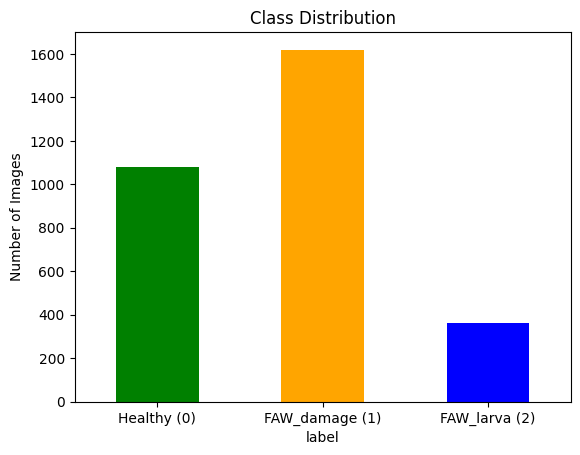

In [17]:
df['label'].value_counts().sort_index().plot(
    kind='bar', color=['green','orange','blue'])
plt.xticks([0,1,2], ['Healthy (0)', 'FAW_damage (1)', 'FAW_larva (2)'], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

### 4.3 Sample Images per Class

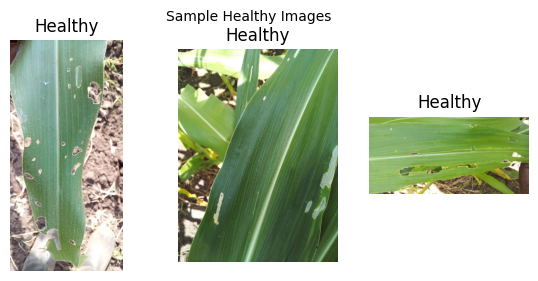

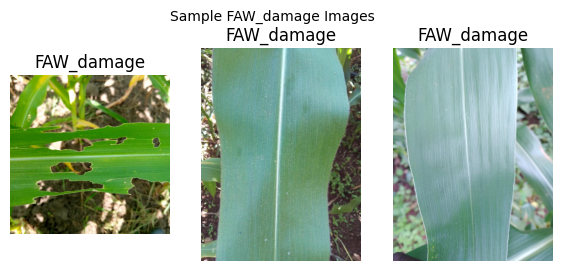

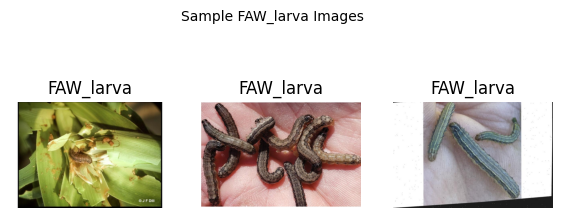

In [18]:
for label, name in zip([0,1,2], ['Healthy','FAW_damage','FAW_larva']):
    samples = df[df['label']==label].sample(3)
    plt.figure(figsize=(7,3))
    for i, row in enumerate(samples.itertuples(), 1):
        img_path = os.path.join(base_dir, row.filename)
        img = mpimg.imread(img_path)
        plt.subplot(1,3,i)
        plt.imshow(img)
        plt.axis('off')
        plt.title(name)
    plt.suptitle(f"Sample {name} Images", fontsize=10)
    plt.show()

### 4.4 Image Size Check

In [19]:
sizes = []
for f in df['filename'].sample(200):  # sample 200 for speed
    path = os.path.join(base_dir, f)
    with Image.open(path) as img:
        sizes.append(img.size)
sizes = np.array(sizes)
print("Average image size (W,H):", sizes.mean(axis=0))

Average image size (W,H): [ 859.245 1014.035]


### 4.5 Average Colour

In [20]:
means = []
for f in df['filename'].sample(100):
    path = os.path.join(base_dir, f)
    img = Image.open(path).convert('RGB')
    arr = np.array(img)/255.0
    means.append(arr.mean(axis=(0,1)))
print("Average RGB means:", np.array(means).mean(axis=0))

Average RGB means: [0.45758326 0.53743444 0.35358033]


## 5.0 **DATA PREPROCESSING**

### 5.1 Label Redefinition for Binary Classification

To align with the project’s primary objective, the original three-class dataset (Healthy, FAW Damage, FAW Larva) was restructured into a binary classification system:

- **FAW Absent (Healthy)** = 0

- **FAW Present (FAW Damage or Larva)** = 1

This transformation focuses the model on **identifying the presence of infestation** rather than differentiating between its manifestations.

In [21]:
base_dir = "/content/drive/My Drive/Colab Notebooks/FAW_Dataset"
csv_path = os.path.join(base_dir, "labels_complete_fixed.csv")
df = pd.read_csv(csv_path)

# Redefining labels for binary classification
df['label'] = df['label'].replace({0: 0, 1: 1, 2: 1})
print("\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
1    1980
0    1080
Name: count, dtype: int64


### 5.2 Data Splitting


In [22]:
# Splitting dataset into train, validation, and test (70,15,15)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"\nData split summary:")
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))


Data split summary:
Train size: 2142
Validation size: 459
Test size: 459


### 5.3 Handling Class Imbalance

In [23]:
classes = np.unique(df['label'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['label'])
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(1.4166666666666667), np.int64(1): np.float64(0.7727272727272727)}


### 5.4 Loading & Preprocessing Images

In [24]:
# Resizing all images to 224×224 and normalizing pixel values (0–1)
IMG_SIZE = (224, 224)

def load_images(df):
    X, y = [], []
    for _, row in df.iterrows():
        img_path = os.path.join(base_dir, row['filename'])
        if os.path.exists(img_path):  # avoid missing files
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img = image.img_to_array(img)  # leave unnormalized (0–255)
            X.append(img)
            y.append(row['label'])
        else:
            print("Missing:", img_path)
    return np.array(X), np.array(y)

X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)
X_test, y_test = load_images(test_df)

print("Shapes:")
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Shapes:
Train: (2142, 224, 224, 3) Validation: (459, 224, 224, 3) Test: (459, 224, 224, 3)


### 5.5 Data Augmentation

In [25]:
# Generating more diverse images for training only
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test sets: only rescale, no augmentation
datagen_val = ImageDataGenerator(rescale=1./255)
datagen_test = ImageDataGenerator(rescale=1./255)

### 5.6 Creating Data Generators

In [26]:
# Converting arrays into generators for training
train_gen = datagen_train.flow(X_train, y_train, batch_size=32)
val_gen = datagen_val.flow(X_val, y_val, batch_size=32)
test_gen = datagen_test.flow(X_test, y_test, batch_size=32, shuffle=False)

print("\nData generators created successfully.")


Data generators created successfully.


### 5.7 Verifying Augmentation

Pixel range: 0.0 to 1.0


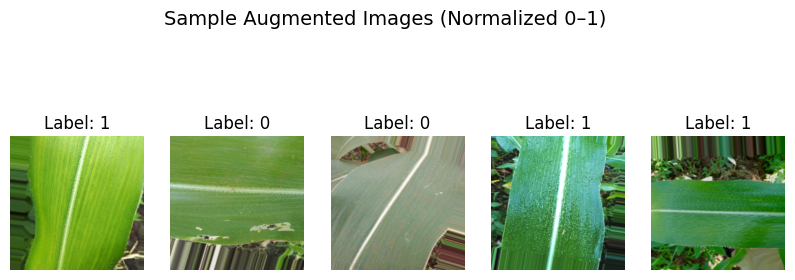

In [27]:
# Visualizing a few augmented images
x_batch, y_batch = next(train_gen)
print("Pixel range:", x_batch.min(), "to", x_batch.max())

plt.figure(figsize=(10,4))
for i in range(5):
    img = np.clip(x_batch[i], 0, 1)  # ensure visible range for matplotlib
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"Label: {int(y_batch[i])}")
    plt.axis('off')
plt.suptitle("Sample Augmented Images (Normalized 0–1)", fontsize=14)
plt.show()